# Notebook principal
Notebook initiale pour le projet AI_Project.

# Projet IA/ML 2026 - Smart School ECAM

## Objectif général

Ce projet vise à utiliser des techniques de Machine Learning pour aider une école à mieux accompagner ses étudiants.

Le projet est composé de deux parties principales :

1. **Failure Prediction** : prédire le score d’un étudiant à un examen afin d’identifier les étudiants à risque.
2. **OCR / Automatic Correction** : reconnaître automatiquement des caractères manuscrits pour faciliter la correction.

Comme je suis en informatique, une attention particulière sera aussi portée aux aspects avancés :
- sécurité,
- biais,
- explicabilité.

# 1. Attentes du professeur

D’après l’énoncé, le projet est évalué sur :

## Partie 1 - Failure Prediction

- Comprendre la structure du dataset.
- Réaliser une analyse exploratoire des données.
- Visualiser les données avec des graphiques pertinents.
- Étudier l’importance des variables.
- Préparer les données :
  - valeurs manquantes,
  - encodage des variables catégorielles,
  - normalisation si nécessaire.
- Comparer plusieurs modèles.
- Utiliser une baseline simple.
- Optimiser les hyperparamètres.
- Analyser l’overfitting et l’underfitting.

## Partie 2 - OCR

- Charger les images.
- Préparer le dataset image.
- Choisir un modèle adapté.
- Entraîner le modèle.
- Évaluer les performances avec une matrice de confusion.

## Partie avancée informatique

- Étudier la sécurité : un étudiant peut-il manipuler ses données ?
- Étudier les biais : certaines variables influencent-elles injustement le modèle ?
- Étudier l’explicabilité : peut-on expliquer pourquoi le modèle prédit un risque d’échec ?

# 2. Plan de travail

Le notebook suivra la démarche suivante :

1. Importation des bibliothèques.
2. Chargement du dataset étudiant.
3. Compréhension générale des données.
4. Analyse des valeurs manquantes.
5. Analyse exploratoire des données.
6. Analyse des variables importantes.
7. Prétraitement des données.
8. Création d’une baseline.
9. Entraînement de plusieurs modèles.
10. Comparaison des performances.
11. Analyse sécurité.
12. Analyse biais.
13. Explicabilité.
14. OCR.
15. Conclusion générale.

# 3. Importation des bibliothèques

Dans cette section, on importe les bibliothèques nécessaires pour :
- manipuler les données,
- visualiser les résultats,
- entraîner des modèles de Machine Learning,
- évaluer les performances.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

# 4. Chargement du dataset

On commence par charger le fichier `train.csv` contenant les données relatives aux étudiants.

Ce dataset sera utilisé pour prédire la variable `score_examen`.

In [5]:
df = pd.read_csv("../data/student_failure/train.csv")

df.head()
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id                        630000 non-null  int64  
 1   age                       630000 non-null  int64  
 2   genre                     630000 non-null  str    
 3   diplôme                   630000 non-null  str    
 4   heures_etude              611100 non-null  float64
 5   assiduité_classe          630000 non-null  float64
 6   accès_internet            567000 non-null  str    
 7   heures_sommeil            630000 non-null  float64
 8   qualité_sommeil           630000 non-null  str    
 9   méthode_etude             585900 non-null  str    
 10  évaluation_établissement  630000 non-null  str    
 11  difficulté_examen         630000 non-null  str    
 12  score_examen              630000 non-null  float64
 13  heures_fête               630000 non-null  int64  
 14 

# 5. Compréhension générale du dataset

Dans cette partie, on observe :
- le nombre de lignes,
- le nombre de colonnes,
- les types de variables,
- les premières valeurs du dataset.

Cela permet d’identifier rapidement les variables numériques, catégorielles et la variable cible.

# 6. Première interprétation des variables

La variable cible est :

- `score_examen` : score obtenu par l’étudiant à l’examen.

Les variables explicatives peuvent être regroupées en plusieurs familles :

## Profil étudiant
- age
- genre
- diplome
- taille_etudiant

## Comportement / habitudes
- heures_etude
- assiduite_classe
- heures_sommeil
- heures_fete

## Conditions d’apprentissage
- acces_internet
- methode_etude
- evaluation_etablissement

## Perception / subjectivité
- qualite_sommeil
- difficulte_examen

Cette séparation est importante car certaines variables sont objectives tandis que d’autres peuvent être manipulées ou biaisées.

# 7. Analyse des valeurs manquantes

On vérifie quelles colonnes contiennent des valeurs manquantes.

Cette étape est importante car les modèles de Machine Learning ne peuvent généralement pas utiliser directement des données incomplètes.

In [7]:
missing_values = df.isnull().sum()
missing_values

missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent.sort_values(ascending=False)

accès_internet              10.0
méthode_etude                7.0
heures_etude                 3.0
genre                        0.0
age                          0.0
diplôme                      0.0
id                           0.0
assiduité_classe             0.0
heures_sommeil               0.0
qualité_sommeil              0.0
évaluation_établissement     0.0
difficulté_examen            0.0
score_examen                 0.0
heures_fête                  0.0
taille_etudiant              0.0
dtype: float64

# 8. Statistiques descriptives

On observe les statistiques principales des variables numériques :
- moyenne,
- écart-type,
- minimum,
- maximum,
- quartiles.

Cela permet de détecter des valeurs extrêmes ou incohérentes.

In [8]:
df.describe()

,id,age,heures_etude,assiduité_classe,heures_sommeil,score_examen,heures_fête,taille_etudiant
count,630000.000000,630000.000000,611100.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,20.545821,4.002779,71.987261,7.072758,63.406789,4.000514,1.754836
std,181865.479132,2.260238,2.359388,17.430098,1.744811,18.950840,2.000382,0.131891
min,0.000000,17.000000,0.080000,40.600000,4.100000,12.600000,0.000000,1.480000
25%,157499.750000,19.000000,1.980000,57.000000,5.600000,49.600000,3.000000,1.660000
50%,314999.500000,21.000000,4.010000,72.600000,7.100000,63.620000,4.000000,1.750000
75%,472499.250000,23.000000,6.050000,87.200000,8.600000,77.300000,5.000000,1.850000
max,629999.000000,24.000000,7.910000,99.400000,9.900000,100.000000,19.000000,2.030000


# 9. Distribution du score d’examen

On visualise la distribution de la variable cible `score_examen`.

Objectif :
- voir si les scores sont équilibrés,
- identifier une éventuelle concentration autour de certaines valeurs,
- détecter des valeurs extrêmes.

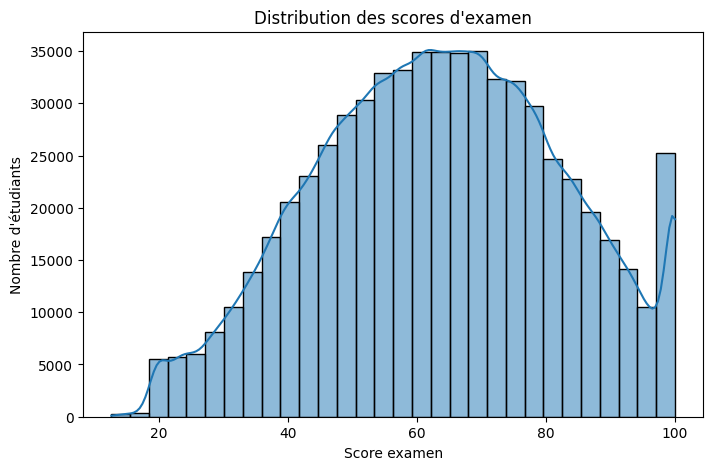

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df["score_examen"], bins=30, kde=True)
plt.title("Distribution des scores d'examen")
plt.xlabel("Score examen")
plt.ylabel("Nombre d'étudiants")
plt.show()

# 10. Corrélation entre variables numériques

On étudie les corrélations entre les variables numériques et le score d’examen.

Cela permet d’identifier les variables qui semblent avoir un lien fort avec la réussite ou l’échec.

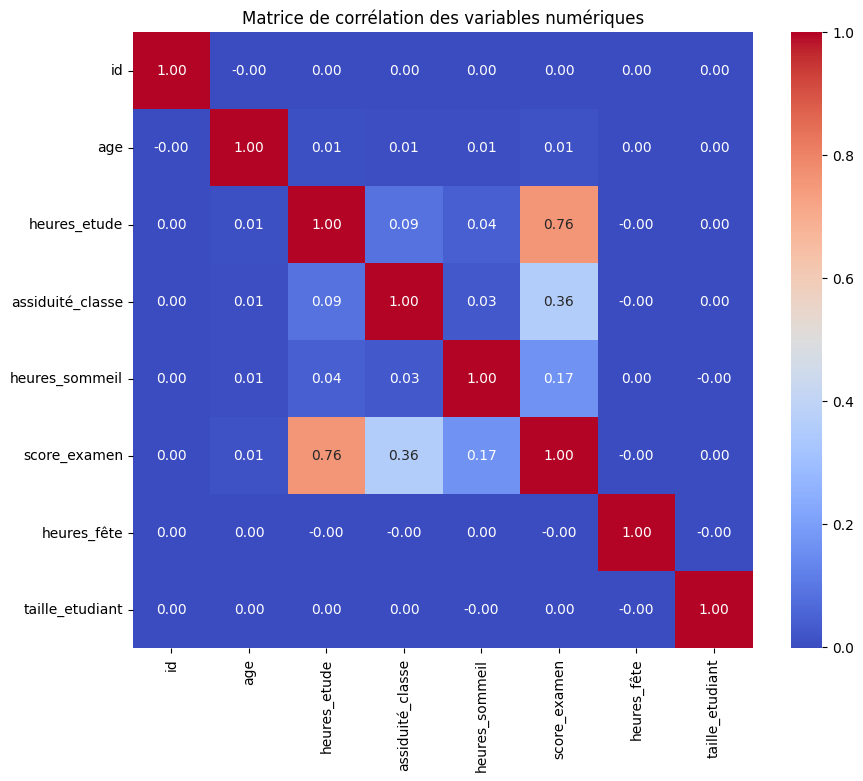

In [10]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation des variables numériques")
plt.show()

# 11. Première analyse sécurité

Certaines variables du dataset semblent déclaratives ou subjectives.

Cela signifie qu’un étudiant pourrait potentiellement modifier ces informations pour influencer la prédiction du modèle.

Variables potentiellement manipulables :
- heures_etude
- heures_sommeil
- heures_fete
- methode_etude
- qualite_sommeil
- difficulte_examen
- acces_internet

Variables plus difficiles à manipuler :
- age
- genre
- diplome
- taille_etudiant
- score_examen

Cette analyse sera approfondie après l’entraînement des modèles, en testant l’impact de petites modifications sur la prédiction.

# 12. Préparation des données pour le Machine Learning

On sépare :
- `X` : les variables explicatives,
- `y` : la variable cible.

On retire `id` car il s’agit d’un identifiant et non d’une vraie information prédictive.

In [11]:
X = df.drop(columns=["score_examen", "id"])
y = df["score_examen"]

X.head()

,age,genre,diplôme,heures_etude,assiduité_classe,accès_internet,heures_sommeil,qualité_sommeil,méthode_etude,évaluation_établissement,difficulté_examen,heures_fête,taille_etudiant
0,21,male,Computer Science,7.91,98.8,NaN,4.9,average,online videos,low,easy,5,1.91
1,18,female,Law,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,4,1.89
2,20,female,Computer Science,4.68,92.6,NaN,5.8,poor,coaching,high,moderate,4,1.72
3,19,male,Computer Science,2.00,49.5,yes,8.3,average,group study,high,moderate,4,1.51
4,23,female,Business Management,7.65,86.9,yes,9.6,good,self-study,high,easy,2,1.94


# 13. Séparation train/test

On sépare les données en deux parties :

- train set : utilisé pour entraîner les modèles,
- test set : utilisé pour évaluer les performances finales.

Cela permet d’évaluer si le modèle généralise bien sur des données jamais vues.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((504000, 13), (126000, 13))

# 14. Prétraitement des données

Les variables numériques et catégorielles doivent être traitées différemment.

Pour les variables numériques :
- remplacement des valeurs manquantes,
- normalisation éventuelle.

Pour les variables catégorielles :
- remplacement des valeurs manquantes,
- encodage One-Hot.

In [13]:
from sklearn.impute import SimpleImputer

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

C:\Users\yayal\AppData\Local\Temp\ipykernel_20960\772609192.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns


# 15. Modèle baseline

La baseline est un modèle très simple qui prédit toujours la moyenne des scores.

Elle sert de référence minimale.

Un bon modèle doit faire mieux que cette baseline.

In [14]:
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DummyRegressor(strategy="mean"))
])

baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)

mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_baseline = r2_score(y_test, y_pred_baseline)

mae_baseline, rmse_baseline, r2_baseline

(15.545894418150164, np.float64(18.897375422654083), -4.240951068457122e-05)

# 16. Modèle 1 — Régression linéaire

La régression linéaire est un modèle simple et interprétable.

Elle permet d’avoir une première idée des relations entre les variables et le score.

In [15]:
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

mae_linear, rmse_linear, r2_linear

(7.402357450555207, np.float64(9.338789560952447), 0.7557713470287113)

# 17. Modèle 2 — Random Forest

Random Forest est un modèle plus puissant, capable de capturer des relations non linéaires.

Il permet aussi d’obtenir une importance des variables.

In [16]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

mae_rf, rmse_rf, r2_rf

(7.5658552469047615, np.float64(9.55715545925799), 0.7442163757852233)

# 18. Comparaison des modèles

On compare les modèles selon plusieurs métriques :

- MAE : erreur absolue moyenne.
- RMSE : pénalise davantage les grosses erreurs.
- R² : proportion de variance expliquée.

Le meilleur modèle doit avoir :
- MAE faible,
- RMSE faible,
- R² élevé.

In [17]:
results = pd.DataFrame({
    "Model": ["Baseline", "Linear Regression", "Random Forest"],
    "MAE": [mae_baseline, mae_linear, mae_rf],
    "RMSE": [rmse_baseline, rmse_linear, rmse_rf],
    "R2": [r2_baseline, r2_linear, r2_rf]
})

results

,Model,MAE,RMSE,R2
0,Baseline,15.545894,18.897375,-0.000042
1,Linear Regression,7.402357,9.338790,0.755771
2,Random Forest,7.565855,9.557155,0.744216


# 19. Partie OCR

Cette partie sera réalisée après la partie Failure Prediction.

Objectif :
- charger les images,
- visualiser quelques exemples,
- entraîner un modèle de classification,
- évaluer avec une matrice de confusion.

# 20. Synthèse globale provisoire

À ce stade, le projet suit la méthodologie attendue :

- compréhension du dataset,
- analyse exploratoire,
- traitement des données,
- baseline,
- comparaison de plusieurs modèles,
- réflexion sur la sécurité,
- préparation de la partie OCR.

Les prochaines étapes seront :
1. approfondir l’EDA,
2. analyser les variables importantes,
3. améliorer les modèles,
4. faire une vraie attaque sécurité,
5. traiter les biais,
6. expliquer les prédictions,
7. terminer l’OCR.